**SVM**

_Adapted from https://scikit-learn.org/stable/auto_examples/svm/plot_iris_svc.html#sphx-glr-auto-examples-svm-plot-iris-svc-py_

## Code Example

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm, datasets

In [2]:
def load_iris_first_2_features_and_binary():
    # import some data to play with
    iris = datasets.load_iris()
    # Take the first two features. We could avoid this by using a two-dim dataset
    X = iris.data[:, :2]
    y = iris.target
    #make it only two classes:
    #y = np.array(iris.target < 1).astype(int) #this is an easier binary problem
    y = np.array(iris.target > 1).astype(int) #this is a harder binary problem
    feature_names = ('Sepal length', 'Sepal width') #x and y
    return X,y,feature_names

def load_lista1_dataset():
    #from numpy import genfromtxt
    my_data = np.genfromtxt('../../datasets/lista1_dataset.csv', delimiter=',')
    X = my_data[:,:2] # two first parameters are input vector
    #y = my_data[:,2:]
    y = np.ravel(my_data[:,2:],order='C') #convert column vector into 1D array
    feature_names = ('x0', 'x1') #x and y
    return X,y,feature_names

def load_simple():
    #from numpy import genfromtxt
    my_data = np.genfromtxt('../../datasets/simple.csv', delimiter=',')
    X = my_data[:,:2] # fish length and weight
    y = np.ravel(my_data[:,2:],order='C') #convert column vector into 1D array
    feature_names = ('Length', 'Weight') #x and y
    return X,y,feature_names

In [3]:
np.random.seed(30) #reproducible experiments

Choose here the dataset

In [4]:
#X,y,feature_names = load_simple()
#X,y,feature_names = load_lista1_dataset()
X,y,feature_names = load_iris_first_2_features_and_binary()

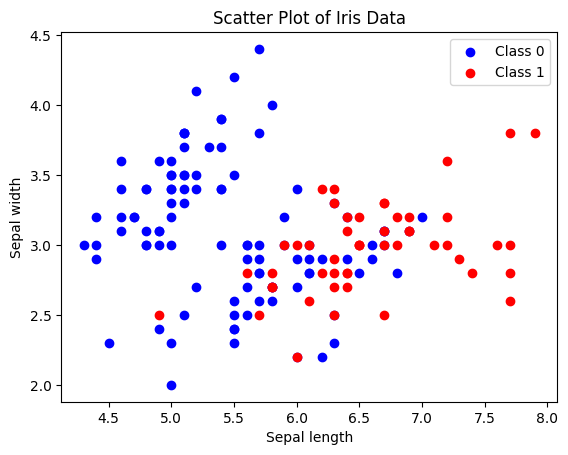

In [5]:
def plot_scatter(X, y, feature_names):
    plt.figure()
    plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='blue', label='Class 0')
    plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='red', label='Class 1')
    plt.xlabel(feature_names[0])
    plt.ylabel(feature_names[1])
    plt.title('Scatter Plot of Iris Data')
    plt.legend()
    plt.show()

# Exemplo de uso:
X, y, feature_names = load_iris_first_2_features_and_binary()
plot_scatter(X, y, feature_names)

In [6]:
def convert_linear_SVM_to_perceptron(support_vectors, dual_coef):
    dual_coef = np.ravel(dual_coef,order='C') #convert to a 1D vector
    num_support_vectors = len(dual_coef)
    if support_vectors.shape[0] != num_support_vectors:
        raise Exception('support_vectors.shape[0] != num_support_vectors')
    input_space_dimension = support_vectors.shape[1]
    perceptron_weights = np.zeros((input_space_dimension))
    for sv in range(num_support_vectors):
        perceptron_weights += dual_coef[sv] * support_vectors[sv]
    return perceptron_weights

def calculate_intercept(perceptron_weights,support_vectors,support_vector_indices,labels):
    '''
    There are different ways to calculate the SVM intercept or bias value.
    This method does not lead to the same results as the ones obtained with scikit-learn.
    In fact, scikit-learn uses the svmlib algorithms, as indicated at
    https://github.com/scikit-learn/scikit-learn/blob/f3f51f9b611bf873bd5836748647221480071a87/sklearn/svm/_base.py#L1049
    Useful references:
    https://stats.stackexchange.com/questions/211310/deriving-the-intercept-term-in-a-linearly-separable-and-soft-margin-svm
    https://stats.stackexchange.com/questions/184272/why-is-the-bias-term-in-svm-estimated-separately-instead-of-an-extra-dimension
    '''
    num_support_vectors = support_vectors.shape[0]
    #input_space_dimension = support_vectors.shape[1]
    max_negative = -1e30
    min_positive = 1e30
    for i in range(num_support_vectors):
        #note that labels has all training examples, not only support vectors,
        #so use support_vector_indices to get the proper index in training set
        this_label = labels[support_vector_indices[i]]
        this_inner_product = np.inner(perceptron_weights, support_vectors[i])
        if this_label > 0:
            if this_inner_product < min_positive:
                min_positive = this_inner_product
        else:
            if this_inner_product > max_negative:
                max_negative = this_inner_product
    return -(max_negative+min_positive)/2.0

def make_meshgrid(x, y, h=.02):
    """Create a mesh of points to plot in

    Parameters
    ----------
    x: data to base x-axis meshgrid on
    y: data to base y-axis meshgrid on
    h: stepsize for meshgrid, optional

    Returns
    -------
    xx, yy : ndarray
    """
    x_min, x_max = x.min() - 1, x.max() + 1
    y_min, y_max = y.min() - 1, y.max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    return xx, yy


def plot_contours(ax, clf, xx, yy, **params):
    """Plot the decision boundaries for a classifier.

    Parameters
    ----------
    ax: matplotlib axes object
    clf: a classifier
    xx: meshgrid ndarray
    yy: meshgrid ndarray
    params: dictionary of params to pass to contourf, optional
    """
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    out = ax.contourf(xx, yy, Z, **params)
    return out

In [7]:
# we create an instance of SVM and fit out data. We do not scale our
# data since we want to plot the support vectors
C = 1  # SVM regularization parameter

svc_with_linear_kernel = svm.SVC(kernel='linear', C=C, verbose=1, shrinking=False)
linear_svc = svm.LinearSVC(C=C, max_iter=10000, dual=True, tol=1e-10)
rbf_svm = svm.SVC(kernel='rbf', gamma=0.7, C=C) #RBF also called Gaussian
polynomial_svm = svm.SVC(kernel='poly', degree=3, gamma='auto', C=C, coef0=0)

In [8]:
print('#### 1) Linear SVM with LinearSVC #####')
#This is restricted to linear SVMs. It does not return the support vectors but the primal perceptron
linear_svc.fit(X,y) #https://scikit-learn.org/stable/modules/generated/sklearn.svm.LinearSVC.html
print('linear_svc.coef_=',linear_svc.coef_)
print('linear_svc.intercept_=',linear_svc.intercept_)
#print(linear_svc.offset_)
svm_scores = np.zeros((4,))
svm_scores[0] = linear_svc.score(X,y)

#### 1) Linear SVM with LinearSVC #####
linear_svc.coef_= [[ 0.66001144 -0.34870356]]
linear_svc.intercept_= [-3.13919621]


In [9]:
#These are generic SVMs
#https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC
svc_with_linear_kernel.fit(X,y)
rbf_svm.fit(X,y) 
polynomial_svm.fit(X,y)

tuple_of_svms = (svc_with_linear_kernel, rbf_svm, polynomial_svm)

print('\n\n#### Generic SVMs with SVC #####')
for i in range(3):
    svm = tuple_of_svms[i]
    print('#### ', str(i+2), ') SVM with SVC ####\n', svm.get_params())
    print('svm.n_support_=',svm.n_support_) #Number of support vectors for each class.
    print('svm.support_=',svm.support_) #Indices of support vectors
    print('svm.support_vectors_=',svm.support_vectors_) #the support vectors
    print('svm.dual_coef_=',svm.dual_coef_) #lambdas
    print('svc.intercept_=',svm.intercept_) #bias
    decisions = svm.decision_function(X)
    if len(decisions) > 10: #don't show too many numbers
        decisions = decisions[:10]
    print('At most 10 decisions: svm.decision_function(X)=',decisions)
    svm_scores[i+1] = svm.score(X,y)
    print('Accuracy via svm.score(X,y)=',svm_scores[i])
    if i == 0: #print(svm.coef_) #cannot be used with non-linear SVMs
        print('svc_with_linear_kernel.coef_=',svm.coef_)
        #print('linear_svc.intercept_=',svm.intercept_)
        perceptron_weights = convert_linear_SVM_to_perceptron(svm.support_vectors_, svm.dual_coef_)
        print('Estimated perceptron_weights=', perceptron_weights)
        bias = calculate_intercept(perceptron_weights,svm.support_vectors_,svm.support_,y)
        print('Estimated bias=', bias)

[LibSVM]*
optimization finished, #iter = 69
obj = -67.107474, rho = -11.356088
nSV = 71, nBSV = 68
Total nSV = 71


#### Generic SVMs with SVC #####
####  2 ) SVM with SVC ####
 {'C': 1, 'break_ties': False, 'cache_size': 200, 'class_weight': None, 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 'scale', 'kernel': 'linear', 'max_iter': -1, 'probability': False, 'random_state': None, 'shrinking': False, 'tol': 0.001, 'verbose': 1}
svm.n_support_= [36 35]
svm.support_= [ 14  15  50  51  52  54  55  56  58  61  62  63  65  67  68  70  71  72
  73  74  75  76  77  78  79  82  83  85  86  87  91  92  95  96  97  99
 100 101 103 104 106 108 110 111 112 113 114 115 116 119 121 123 124 126
 127 128 132 133 134 136 137 138 140 142 143 144 145 146 147 148 149]
svm.support_vectors_= [[5.8 4. ]
 [5.7 4.4]
 [7.  3.2]
 [6.4 3.2]
 [6.9 3.1]
 [6.5 2.8]
 [5.7 2.8]
 [6.3 3.3]
 [6.6 2.9]
 [5.9 3. ]
 [6.  2.2]
 [6.1 2.9]
 [6.7 3.1]
 [5.8 2.7]
 [6.2 2.2]
 [5.9 3.2]
 [6.1 2.8]
 [6.3 2.

('LinearSVC (linear kernel)', 'SVC with linear kernel', 'SVC with RBF kernel', 'SVC with polynomial (degree 3) kernel') have accuracies:
svm_scores= [0.80666667 0.82       0.82666667 0.81333333]


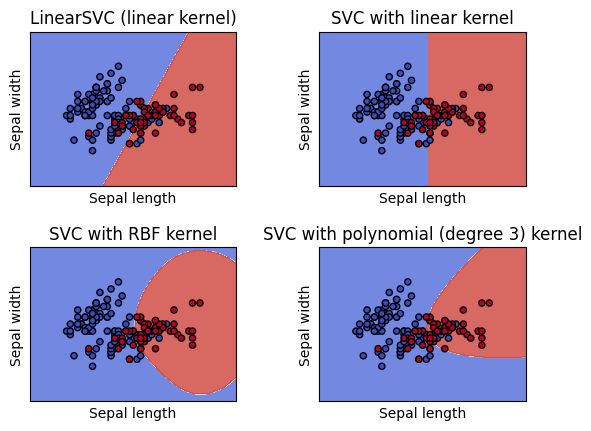

In [10]:
#Plot:
models = (linear_svc, svc_with_linear_kernel, rbf_svm, polynomial_svm)

# title for the plots
titles = ('LinearSVC (linear kernel)',
        'SVC with linear kernel',
        'SVC with RBF kernel',
        'SVC with polynomial (degree 3) kernel')

# Set-up 2x2 grid for plotting.
fig, sub = plt.subplots(2, 2)
plt.subplots_adjust(wspace=0.4, hspace=0.4)

X0, X1 = X[:, 0], X[:, 1]
xx, yy = make_meshgrid(X0, X1)

for clf, title, ax in zip(models, titles, sub.flatten()):
    plot_contours(ax, clf, xx, yy,
                  cmap=plt.cm.coolwarm, alpha=0.8)
    ax.scatter(X0, X1, c=y, cmap=plt.cm.coolwarm, s=20, edgecolors='k')
    ax.set_xlim(xx.min(), xx.max())
    ax.set_ylim(yy.min(), yy.max())
    ax.set_xlabel(feature_names[0])
    ax.set_ylabel(feature_names[1])
    ax.set_xticks(())
    ax.set_yticks(())
    ax.set_title(title)

print(titles,'have accuracies:')
print('svm_scores=',svm_scores)
plt.show()